In [28]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
569,2023,SE,FT,Data Analyst,135000,USD,135000,US,0,US,M
2660,2022,SE,FT,Data Architect,180000,USD,180000,US,100,US,M
2544,2022,SE,FT,Data Scientist,185900,USD,185900,US,0,US,M
2252,2022,SE,FT,Data Scientist,122600,USD,122600,US,0,US,M
3259,2022,SE,FT,Data Analyst,120600,USD,120600,US,100,US,M
2182,2022,SE,FT,Data Analyst,100000,USD,100000,US,0,US,M
2607,2022,SE,FT,Data Scientist,130000,USD,130000,US,100,US,M
1554,2023,SE,FT,Data Engineer,205600,USD,205600,US,0,US,L
1255,2023,SE,FT,Data Engineer,213580,USD,213580,US,100,US,M
3276,2022,SE,FT,Data Analyst,170000,USD,170000,US,100,US,M


Number of dataset samples: 3755


,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
894,2023,SE,FT,Data Analyst,120000,100,US,M
3253,2022,SE,FT,Data Scientist,120000,0,US,L
3421,2022,MI,FT,Machine Learning Engineer,120000,100,US,S
3283,2022,SE,FT,Data Engineer,61566,0,GB,M
617,2023,SE,FT,Data Engineer,163800,0,US,M


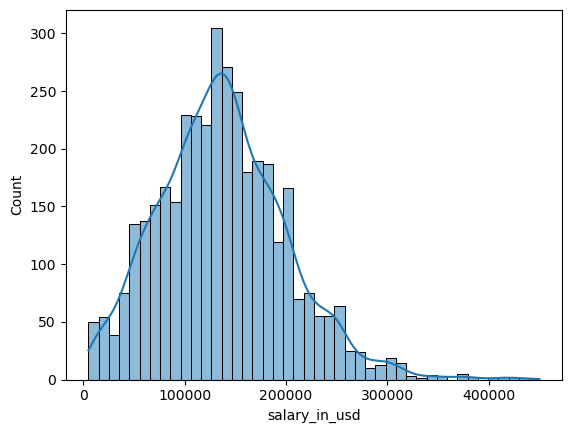

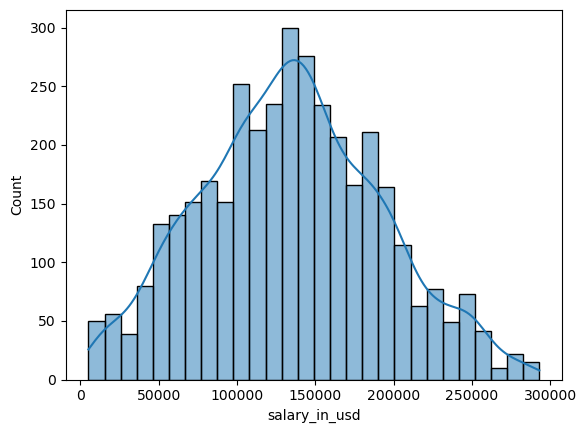

2023    1747
2022    1644
2021     228
2020      73
Name: work_year, dtype: int64
SE    2473
MI     800
EN     319
EX     100
Name: experience_level, dtype: int64
FT    3656
PT      17
FL      10
CT       9
Name: employment_type, dtype: int64
Data Engineer                               1024
Data Scientist                               830
Data Analyst                                 610
Machine Learning Engineer                    283
Analytics Engineer                           103
Data Architect                                99
Research Scientist                            78
Applied Scientist                             55
Data Science Manager                          51
Research Engineer                             37
ML Engineer                                   34
Data Manager                                  29
Machine Learning Scientist                    26
Data Science Consultant                       24
Data Analytics Manager                        22
Computer Vision Engine

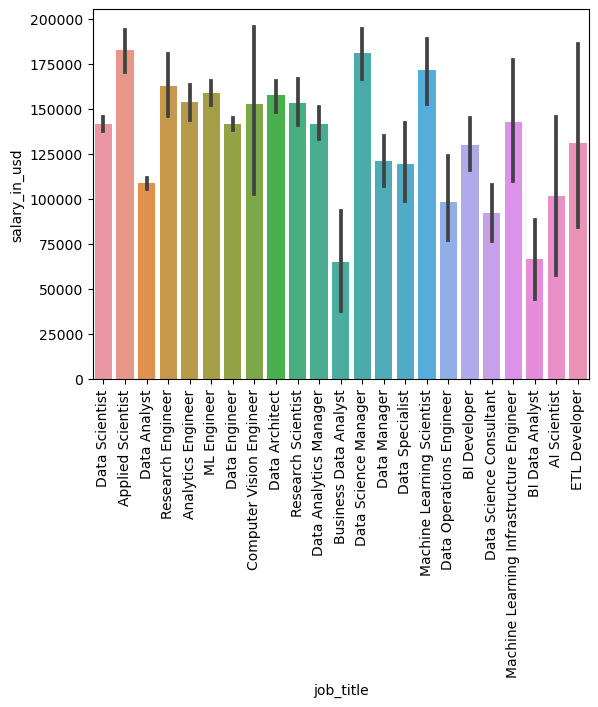

                                                   mean           std     min  \
job_title                                                                       
AI Scientist                              101741.000000  82967.055311   12000   
Analytics Engineer                        153788.911765  52129.175655   48000   
Applied Scientist                         183028.000000  42459.835341   72000   
BI Data Analyst                            66576.000000  41640.599291    6270   
BI Developer                              129846.153846  27370.440728  100000   
Business Data Analyst                      65156.583333  50703.151472    9289   
Computer Vision Engineer                  153016.500000  88589.268371   15897   
Data Analyst                              108773.159129  43151.078182    5723   
Data Analytics Manager                    141879.090909  20849.716661  105400   
Data Architect                            157691.020202  45459.232607   63000   
Data Engineer               

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
553,0.906143,-1.773063,-0.057831,0.766153,145000,-0.913400,0.372566,0.209578
3432,-2.210347,-0.612590,-0.057831,0.766153,109000,0.108370,0.372566,-2.758688
69,0.906143,0.547884,-0.057831,-2.015026,159100,-0.913400,0.372566,-2.758688
1021,0.906143,-0.612590,-0.057831,-0.303531,100000,-0.913400,0.372566,0.209578
3298,-0.652102,0.547884,-0.057831,-0.945342,112900,1.130139,0.372566,0.209578
1353,0.906143,-1.773063,-0.057831,-0.731405,140000,-0.913400,0.372566,0.209578
2995,-0.652102,0.547884,-0.057831,1.407964,164996,-0.913400,0.372566,0.209578
519,0.906143,0.547884,-0.057831,0.766153,275300,1.130139,0.372566,0.209578
291,0.906143,0.547884,-0.057831,0.766153,145000,1.130139,0.372566,0.209578
250,0.906143,-2.933537,-0.057831,-0.303531,85000,-0.913400,0.372566,0.209578


In [46]:
#____________________________ part a and b ______________________________#
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import OrdinalEncoder, StandardScaler 

data = pd.read_csv('ds_salaries.csv')
data.sample(10)

data = data.dropna()
print(f"Number of dataset samples: {data.shape[0]}")

#filtered_rows = data[data['company_location'] == 'IR']
#filtered_rows.head()

data.drop(columns=['salary','salary_currency','employee_residence'],inplace=True)
data.sample(5)

_=sns.histplot(data['salary_in_usd'],kde=True)
plt.show()

def delete_outlier(df,attr):
    Q1=df[attr].quantile(0.25)
    Q3=df[attr].quantile(0.75)
    IQR=Q3-Q1
    lower_limit=Q1-1.5*IQR
    upper_limit=Q3+1.5*IQR
    return df[(df[attr]>=lower_limit)&(df[attr]<=upper_limit)]

data=delete_outlier(data,'salary_in_usd')

_=plt.figure()
_=sns.histplot(data['salary_in_usd'],kde=True)
plt.show()

# Set the display option to show all rows
pd.set_option('display.max_rows', None)

for attr in list(data.columns):
    if attr== 'salary' or attr=='salary_in_usd':
        continue
    print(data[attr].value_counts())

for attr in ['company_location', 'employment_type', 'job_title']:
    # Count the occurrences of each unique value in attribute
    attr_counts = data[attr].value_counts()

    # Create a boolean mask to filter out rows with less than 10 instances
    mask = data[attr].isin(attr_counts[attr_counts >= 10].index)

    # Apply the mask to the DataFrame to keep only rows with at least 10 instances
    data = data[mask]

mask = ~(data['company_location'].isin(['MX', 'AU']))
data=data[mask]

for attr in list(data.columns):
    if attr!='salary_in_usd':
        print(data[attr].value_counts())

# Replace 'Machine Learning Engineer' with 'ML Engineer'
data['job_title'] = data['job_title'].replace('Machine Learning Engineer', 'ML Engineer')

_=plt.figure()
_=sns.barplot(x=data['job_title'], y=data['salary_in_usd'])
_=plt.xticks(rotation="vertical")
plt.show()

# Calculate statistics for 'salary_in_usd' grouped by 'job_title'
statistics = data.groupby('job_title')['salary_in_usd'].agg(['mean', 'std', 'min', 'max'])

# Calculate range (max-min) for 'salary_in_usd' grouped by 'job_title'
statistics['range'] = statistics['max'] - statistics['min']

# Print the statistics
print(statistics)

# Select the non-numeric features
non_numeric_features = list(data.columns)
non_numeric_features.remove('salary_in_usd')

# Create a subset of the DataFrame with only the non-numeric features
data_non_numeric = data[non_numeric_features]

# Initialize the OrdinalEncoder
encoder = OrdinalEncoder()

# Fit and transform the non-numeric features
data_non_numeric_encoded = encoder.fit_transform(data_non_numeric)

# Replace the non-numeric features in the original DataFrame with the encoded values
data[non_numeric_features] = data_non_numeric_encoded

# Create a subset of the DataFrame with all features except 'salary_in_usd'
features_to_scale = data.drop('salary_in_usd', axis=1)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features to be scaled
scaled_features = scaler.fit_transform(features_to_scale)

# Replace the scaled features in the original DataFrame
data[features_to_scale.columns] = scaled_features
data.sample(10)


In [47]:
#____________________________ part c ______________________________#
from sklearn.model_selection import train_test_split

# Separate the data and target
X = data.drop('salary_in_usd', axis=1)
y = data['salary_in_usd']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

# Print the shapes of the train and test sets
print("Train data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Train target shape:", y_train.shape)
print("Test target shape:", y_test.shape)


Train data shape: (2640, 7)
Test data shape: (660, 7)
Train target shape: (2640,)
Test target shape: (660,)


In [54]:
#____________________________ part d ______________________________#
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# Train a decision tree classifier with depth=2
decision_tree = DecisionTreeClassifier(max_depth=2, random_state=30)
decision_tree.fit(X_train[['experience_level', 'remote_ratio', 'company_size']], y_train)

# Predict the leaf indices for each sample in the train data
leaf_indices_train = decision_tree.apply(X_train[['experience_level', 'remote_ratio', 'company_size']])

# Use polynomial regression to predict targets for each leaf in the train data
poly_reg = PolynomialFeatures(degree=2)
X_train_poly = poly_reg.fit_transform(leaf_indices_train.reshape(-1, 1))
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict the targets for the train data
y_pred_train = poly_model.predict(X_train_poly)

# Calculate MSE and R2-score on the train data
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Print MSE and R2-score for the train data
print("Train MSE:", mse_train)
print("Train R2-score:", r2_train)


DecisionTreeClassifier(max_depth=2, random_state=30)

LinearRegression()

Train MSE: 2668416349.3830247
Train R2-score: 0.15028564271628675


In [55]:
#____________________________ part e ______________________________#

# Predict the leaf indices for each sample in the test data
leaf_indices_test = decision_tree.apply(X_test[['experience_level', 'remote_ratio', 'company_size']])

# Use polynomial regression to predict targets for each leaf in the test data
X_test_poly = poly_reg.transform(leaf_indices_test.reshape(-1, 1))
y_pred_test = poly_model.predict(X_test_poly)

# Calculate MSE and R2-score on the test data
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print MSE and R2-score for the test data
print("Test MSE:", mse_test)
print("Test R2-score:", r2_test)


Test MSE: 2502211645.660949
Test R2-score: 0.1248615452185482
